# Laboratorio 7 – Spark MLlib 
**CC3066 – Data Science · Semestre II – 2026 · Universidad del Valle de Guatemala**

**Integrantes:** Jonathan Zacarias 231104, Mario Rocha 23501
**Repositorio Git:** https://github.com/Zacatac23/Laboratorio-7-Spark.git

Este notebook responde dos preguntas con las bases de Personas de la ENEIC (INE Guatemala, 2025T1–2026T1): qué perfiles de trabajadores asalariados se identifican (segmentación) y qué tan bien se estima su salario mensual (`P05D01`) con características personales y laborales (predicción). Cubre carga y calidad de datos (ej. 1), estadística descriptiva (ej. 2), correlaciones (ej. 3), segmentación con KMeans (ej. 4), regresión lineal (ej. 5) y Random Forest (ej. 6), con validación en 2025T4.

> **Alcance:** los resultados describen a los **registros analizados** (no ponderados). No son estimaciones oficiales de la población guatemalteca ni relaciones causales.

Cuando terminen los ejercicios 7 y 8, agrega al final de la primera frase: "…, prueba final en 2026T1 (ej. 7) y análisis de errores (ej. 8)". Además, cambia el título "(AVANCE)" de la celda anterior.

## 0. Configuración y sesión de Spark

In [1]:
import os, shutil
os.environ["JAVA_HOME"] = os.path.dirname(os.path.dirname(os.path.realpath(shutil.which("java"))))
print("JAVA_HOME =", os.environ["JAVA_HOME"])

JAVA_HOME = /usr/lib/jvm/java-17-openjdk-arm64


In [2]:
!pip install openpyxl --user

In [3]:
!java -version
!echo $JAVA_HOME
!which java

openjdk version "17.0.20.1" 2026-08-18
OpenJDK Runtime Environment (build 17.0.20.1+1-1-deb12u1-Debian)
OpenJDK 64-Bit Server VM (build 17.0.20.1+1-1-deb12u1-Debian, mixed mode, sharing)
/usr/lib/jvm/java-17-openjdk-arm64
/usr/bin/java


In [4]:
import os, math, warnings
from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50, "display.width", 200)

spark = (SparkSession.builder
         .appName("Lab7_ENEIC")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/29 01:24:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1


In [5]:
# ===================== CONFIGURACIÓN (EDITAR) =====================
# periodo_archivo -> ruta del archivo de Personas (Excel .xlsx o .csv)
ARCHIVOS = {
    "2025T1": "./data/Personas_ENEIC_T1_2025.xlsx",
    "2025T2": "./data/Personas-ENEIC-T2-2025.xlsx",
    "2025T3": "./data/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    "2025T4": "./data/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    "2026T1": "./data/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
}
PERIODOS_2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]
PERIODO_2026  = "2026T1"

DIR_STAGE = "./data/parquet/stage"      # una carpeta Parquet por archivo (columnas seleccionadas)
DIR_OUT   = "./data/parquet"            # conjuntos preparados 2025 y 2026
SEED = 42

# Códigos válidos según el diccionario. Si se deja en None se toman los códigos numéricos
# observados en 2025 (y se imprimen para que los contraste con el diccionario).
NIVEL_VALIDOS   = None   # ej.: {"0","1","2","3","4","5","6","7"}   <- verificar con el diccionario
DOMINIO_VALIDOS = None   # ej.: {"1","2","3","4"}                     <- verificar con el diccionario

CAT_LABELS = {"1": "Gobierno", "2": "Empresa privada", "3": "Jornalero/peón", "4": "Servicio doméstico"}

# Columnas originales que se conservan
COLS_TEXTO = ["NUM_HOGAR", "NUM_PERSONA", "DOMINIO", "P03A03A", "P05C16", "OCUPADOS"]
COLS_NUM   = ["P05D01", "P02A03", "P05C07A", "P05C07B", "P05H01A", "FACTOR", "ANIO", "TRIMESTRE"]
COLS_SEL   = COLS_TEXTO + COLS_NUM
for d in (DIR_STAGE, DIR_OUT): os.makedirs(d, exist_ok=True)

---
# Sección 1 · Análisis exploratorio avanzado y segmentación
## 1. Carga, armonización y calidad de datos
**Estrategia:** cada Excel se lee **individualmente** con pandas (solo las columnas necesarias, para controlar memoria), se normalizan los códigos a texto consistente (un mismo código puede llegar como `2`, `2.0` o `"2"`), se convierte a DataFrame de Spark con **esquema explícito** y se guarda en Parquet. Después todo el trabajo es en Spark.

In [6]:
SCHEMA = T.StructType(
    [T.StructField(c, T.StringType(), True) for c in COLS_TEXTO] +
    [T.StructField(c, T.DoubleType(), True) for c in COLS_NUM]
)

def _norm_codigo(s: pd.Series) -> pd.Series:
    """Texto limpio: quita espacios, '2.0' -> '2', vacíos/nan -> None."""
    s = s.astype(object).where(s.notna(), None)
    s = s.map(lambda v: None if v is None else str(v).strip())
    s = s.str.replace(r"^(-?\d+)\.0+$", r"\1", regex=True)
    return s.where(~s.isin(["", "nan", "NaN", "None", "NULL"]), None)

def leer_a_parquet(periodo: str, ruta: str) -> dict:
    """Lee un archivo, homologa tipos, escribe Parquet y devuelve métricas de auditoría."""
    ext = os.path.splitext(ruta)[1].lower()
    filtro = lambda c: str(c).strip().upper() in COLS_SEL
    if ext in (".xlsx", ".xlsm", ".xls"):
        n_cols = pd.read_excel(ruta, nrows=0).shape[1]
        pdf = pd.read_excel(ruta, usecols=filtro, engine="openpyxl")
    else:
        n_cols = pd.read_csv(ruta, nrows=0).shape[1]
        pdf = pd.read_csv(ruta, usecols=filtro, low_memory=False)
    pdf.columns = [str(c).strip().upper() for c in pdf.columns]
    faltan = [c for c in COLS_SEL if c not in pdf.columns]
    if faltan:
        raise ValueError(f"{periodo}: faltan columnas {faltan}")
    pdf = pdf[COLS_SEL]

    for c in COLS_TEXTO:
        pdf[c] = _norm_codigo(pdf[c])
    for c in COLS_NUM:
        pdf[c] = pd.to_numeric(pdf[c], errors="coerce").astype("float64")
        pdf[c] = pdf[c].astype(object).where(pdf[c].notna(), None)   # NaN -> null

    sdf = spark.createDataFrame(pdf.astype(object).where(pdf.notna(), None), schema=SCHEMA)
    (sdf.write.mode("overwrite").parquet(f"{DIR_STAGE}/{periodo}"))
    return {"periodo_archivo": periodo, "archivo_origen": os.path.basename(ruta),
            "registros_originales": len(pdf), "columnas_originales": n_cols}

auditoria_carga = []
for per, ruta in ARCHIVOS.items():
    print("Procesando", per, "...")
    auditoria_carga.append(leer_a_parquet(per, ruta))
auditoria_carga = pd.DataFrame(auditoria_carga)
auditoria_carga

Procesando 2025T1 ...


Procesando 2025T2 ...
Procesando 2025T3 ...
Procesando 2025T4 ...
Procesando 2026T1 ...


,periodo_archivo,archivo_origen,registros_originales,columnas_originales
0,2025T1,Personas_ENEIC_T1_2025.xlsx,51588,270
1,2025T2,Personas-ENEIC-T2-2025.xlsx,51167,270
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,51583,270
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,49338,302
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,49843,270


**Nota:** IV de 2025 trae más columnas (302 vs 270) y en un orden que puede diferir. Por eso las bases se combinan **por nombre** (`unionByName`) y no por posición.

In [7]:
def cargar_periodo(per: str):
    """Lee el Parquet de un archivo y agrega columnas de procedencia (no toca TRIMESTRE original)."""
    anio, tri = int(per[:4]), int(per[-1])
    return (spark.read.parquet(f"{DIR_STAGE}/{per}")
            .withColumn("periodo_archivo", F.lit(per))
            .withColumn("anio_archivo", F.lit(anio))
            .withColumn("trimestre_calendario", F.lit(tri))
            .withColumn("archivo_origen", F.lit(os.path.basename(ARCHIVOS[per]))))

df25 = reduce(lambda a, b: a.unionByName(b), [cargar_periodo(p) for p in PERIODOS_2025]).cache()
df26 = cargar_periodo(PERIODO_2026).cache()
print("Registros 2025 (4 archivos):", df25.count(), "| Registros 2026:", df26.count())
df25.printSchema()
df25.show(5, truncate=False)

Registros 2025 (4 archivos): 203676 | Registros 2026: 49843
root
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- OCUPADOS: string (nullable = true)
 |-- P05D01: double (nullable = true)
 |-- P02A03: double (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: double (nullable = true)
 |-- TRIMESTRE: double (nullable = true)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- archivo_origen: string (nullable = false)

+---------+-----------+-------+-------+------+--------+------+------+-------+-------+-------+------+------+---------+---------------+------------+--------------------+------------------------

In [8]:
# Auditoría del campo TRIMESTRE original (se conserva, no se usa como trimestre calendario)
(df25.unionByName(df26).groupBy("periodo_archivo", "TRIMESTRE").count()
     .orderBy("periodo_archivo", "TRIMESTRE").show())

+---------------+---------+-----+
|periodo_archivo|TRIMESTRE|count|
+---------------+---------+-----+
|         2025T1|      2.0|51588|
|         2025T2|      2.0|  175|
|         2025T2|      3.0|50992|
|         2025T3|      4.0|51583|
|         2025T4|      5.0|49338|
|         2026T1|      6.0|49843|
+---------------+---------+-----+



### 1.1 Faltantes por variable (antes de aplicar filtros)

In [9]:
def faltantes(df, cols_txt, cols_num):
    n = df.count()
    exprs = []
    for c in cols_txt:
        exprs.append(F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c))
    for c in cols_num:
        exprs.append(F.sum(F.when(F.col(c).isNull() | F.isnan(c), 1).otherwise(0)).alias(c))
    fila = df.agg(*exprs).first().asDict()
    out = pd.DataFrame({"variable": list(fila.keys()), "faltantes": list(fila.values())})
    out["pct_faltantes"] = (100 * out["faltantes"] / n).round(2)
    return out

falt25 = faltantes(df25, COLS_TEXTO, COLS_NUM)
falt25

,variable,faltantes,pct_faltantes
0,NUM_HOGAR,0,0.00
1,NUM_PERSONA,0,0.00
2,DOMINIO,0,0.00
3,P03A03A,26344,12.93
4,P05C16,115454,56.69
5,OCUPADOS,115454,56.69
6,P05D01,150651,73.97
7,P02A03,0,0.00
8,P05C07A,115454,56.69
9,P05C07B,115454,56.69


In [10]:
# Faltantes por archivo (para detectar si algún archivo concentra los vacíos)
partes = []
for p in PERIODOS_2025 + [PERIODO_2026]:
    d = (df25 if p in PERIODOS_2025 else df26).filter(F.col("periodo_archivo") == p)
    t = faltantes(d, COLS_TEXTO, COLS_NUM).set_index("variable")["pct_faltantes"].rename(p)
    partes.append(t)
pd.concat(partes, axis=1)

,2025T1,2025T2,2025T3,2025T4,2026T1
variable,,,,,
NUM_HOGAR,0.00,0.00,0.00,0.00,0.00
NUM_PERSONA,0.00,0.00,0.00,0.00,0.00
DOMINIO,0.00,0.00,0.00,0.00,0.00
P03A03A,13.43,13.05,12.69,12.55,12.06
P05C16,56.83,56.33,56.63,56.96,56.40
OCUPADOS,56.83,56.33,56.63,56.96,56.40
P05D01,73.99,73.63,73.93,74.33,73.40
P02A03,0.00,0.00,0.00,0.00,0.00
P05C07A,56.83,56.33,56.63,56.96,56.40


**Interpretación de faltantes.** Las variables que dependen de tener un empleo asalariado —`P05C16`, `OCUPADOS`, `P05C07A`, `P05C07B` y `P05H01A`— faltan en una proporción casi idéntica entre archivos (56.3 %–57.0 %): esto no es ruido de captura, sino el diseño del cuestionario, que solo pregunta por esas variables a quienes están ocupados. `P05D01` (el salario) falta todavía más (73.4 %–74.3 %), porque además de los no ocupados incluye a ocupados que no son asalariados (independientes, patronos, familiares no remunerados). `P03A03A` (nivel educativo) falta solo ~12–13 % y sí corresponde a todas las personas, por lo que ese faltante es más cercano a una no respuesta real que a un "no corresponde" estructural. El patrón por archivo es estable en el tiempo, lo que sugiere que el faltante es estructural (por diseño) y no un problema de calidad puntual de algún trimestre.

### 1.2 Construcción de variables analíticas y reglas de preparación
Las reglas se aplican **siempre en el mismo orden** y se contabilizan los excluidos en cada paso, separando los que **no pudieron evaluarse** (dato nulo/no numérico) de los que **incumplen** el criterio. El salario **no se imputa**.

Orden de filtrado:
1. Edad finita y ≥ 15 · 2. `OCUPADOS = 1` · 3. `P05C16 ∈ {1,2,3,4}` · 4. Salario finito y > 0 · 5. Antigüedad evaluable (años y meses presentes) · 6. Meses entero entre 0 y 11 · 7. Años de antigüedad ≥ 0 · 8. Antigüedad total ≤ edad · 9. Horas habituales > 0 y ≤ 168.

In [11]:
def es_finito(c):   # numérico no nulo, no NaN, no infinito
    col = F.col(c)
    return col.isNotNull() & ~F.isnan(col) & (F.abs(col) != float("inf"))

def con_variables_analiticas(df):
    return (df
        .withColumn("salario_mensual", F.col("P05D01"))
        .withColumn("edad", F.col("P02A03"))
        .withColumn("antiguedad_anios", F.col("P05C07A"))
        .withColumn("antiguedad_meses", F.col("P05C07B"))
        .withColumn("antiguedad", F.col("P05C07A") + F.col("P05C07B") / 12.0)
        .withColumn("horas_semanales", F.col("P05H01A"))
        .withColumn("ocupado", F.col("OCUPADOS"))
        .withColumn("nivel_raw", F.col("P03A03A"))
        .withColumn("categoria_raw", F.col("P05C16"))
        .withColumn("dominio_raw", F.col("DOMINIO")))

# (nombre, condición, columnas de entrada [(col, 'num'|'str')])
PASOS = [
    ("1. edad finita y >= 15",           es_finito("edad") & (F.col("edad") >= 15), [("edad","num")]),
    ("2. ocupado = 1",                   F.col("ocupado") == "1",                    [("ocupado","str")]),
    ("3. P05C16 en {1,2,3,4}",           F.col("categoria_raw").isin("1","2","3","4"), [("categoria_raw","str")]),
    ("4. salario finito y > 0",          es_finito("salario_mensual") & (F.col("salario_mensual") > 0), [("salario_mensual","num")]),
    ("5. antigüedad evaluable (años y meses)", es_finito("antiguedad_anios") & es_finito("antiguedad_meses"),
                                         [("antiguedad_anios","num"),("antiguedad_meses","num")]),
    ("6. meses entero en [0, 11]",       (F.col("antiguedad_meses") >= 0) & (F.col("antiguedad_meses") <= 11) &
                                         (F.col("antiguedad_meses") == F.floor("antiguedad_meses")), [("antiguedad_meses","num")]),
    ("7. antigüedad (años) >= 0",        F.col("antiguedad_anios") >= 0,             [("antiguedad_anios","num")]),
    ("8. antigüedad <= edad",            F.col("antiguedad") <= F.col("edad"),       [("antiguedad","num"),("edad","num")]),
    ("9. horas en (0, 168]",             es_finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168),
                                         [("horas_semanales","num")]),
]

def _nulo(col, tipo):
    return F.col(col).isNull() | (F.isnan(col) if tipo == "num" else F.lit(False))

def aplicar_filtros(df, pasos=PASOS, verbose=True):
    """Aplica los pasos en orden. Devuelve (df filtrado, tabla de conteos por paso y archivo)."""
    actual = con_variables_analiticas(df)
    filas = []
    for nombre, cond, ins in pasos:
        c = F.coalesce(cond, F.lit(False))
        nulo_any = reduce(lambda a, b: a | b, [_nulo(cn, t) for cn, t in ins])
        r = (actual.groupBy("periodo_archivo")
                   .agg(F.count("*").alias("entran"),
                        F.sum(F.when(~c, 1).otherwise(0)).alias("excluidos"),
                        F.sum(F.when(~c & nulo_any, 1).otherwise(0)).alias("no_evaluables"))
                   .toPandas())
        r.insert(0, "paso", nombre)
        filas.append(r)
        actual = actual.filter(c)
    tabla = pd.concat(filas, ignore_index=True)
    return actual, tabla

def normalizar_categoricas(df, nivel_validos, dominio_validos):
    def val(colname, validos):
        c = F.col(colname)
        return F.when(c.isNotNull() & c.isin(*sorted(validos)), c).otherwise(F.lit("DESCONOCIDO"))
    return (df
        .withColumn("nivel_educativo", val("nivel_raw", nivel_validos))
        .withColumn("categoria_ocupacional", val("categoria_raw", {"1","2","3","4"}))
        .withColumn("dominio", val("dominio_raw", dominio_validos)))

In [12]:
# Códigos observados (en 2025) para contrastar contra el diccionario de datos
for c in ["P03A03A", "DOMINIO", "P05C16", "OCUPADOS"]:
    print(f"--- {c} ---")
    df25.groupBy(c).count().orderBy(c).show(50, truncate=False)

--- P03A03A ---
+-------+-----+
|P03A03A|count|
+-------+-----+
|NULL   |26344|
|0      |23751|
|1      |7169 |
|2      |75495|
|3      |24655|
|4      |33959|
|5      |11158|
|6      |1053 |
|7      |92   |
+-------+-----+

--- DOMINIO ---
+-------+-----+
|DOMINIO|count|
+-------+-----+
|1      |67521|
|2      |78570|
|3      |57585|
+-------+-----+

--- P05C16 ---
+------+------+
|P05C16|count |
+------+------+
|NULL  |115454|
|1     |6575  |
|2     |28702 |
|3     |13842 |
|4     |3906  |
|5     |20951 |
|6     |2624  |
|7     |6746  |
|8     |418   |
|9     |4458  |
+------+------+

--- OCUPADOS ---
+--------+------+
|OCUPADOS|count |
+--------+------+
|NULL    |115454|
|1       |88222 |
+--------+------+



In [13]:
def _observados(df, col):
    return {r[0] for r in df.select(col).where(F.col(col).rlike(r"^-?\d+$")).distinct().collect()}

if NIVEL_VALIDOS is None:
    NIVEL_VALIDOS = _observados(df25, "P03A03A")
    print("⚠ NIVEL_VALIDOS tomado de lo observado (confirme con el diccionario):", sorted(NIVEL_VALIDOS))
if DOMINIO_VALIDOS is None:
    DOMINIO_VALIDOS = _observados(df25, "DOMINIO")
    print("⚠ DOMINIO_VALIDOS tomado de lo observado (confirme con el diccionario):", sorted(DOMINIO_VALIDOS))

⚠ NIVEL_VALIDOS tomado de lo observado (confirme con el diccionario): ['0', '1', '2', '3', '4', '5', '6', '7']
⚠ DOMINIO_VALIDOS tomado de lo observado (confirme con el diccionario): ['1', '2', '3']


In [14]:
# ---- Filtros 2025 ----
f25, tabla_pasos25 = aplicar_filtros(df25)
base25 = normalizar_categoricas(f25, NIVEL_VALIDOS, DOMINIO_VALIDOS)

# ---- Filtros 2026 (mismas reglas y mismos códigos válidos definidos con 2025) ----
f26, tabla_pasos26 = aplicar_filtros(df26)
base26 = normalizar_categoricas(f26, NIVEL_VALIDOS, DOMINIO_VALIDOS)

def resumen_pasos(t):
    piv = t.pivot(index="paso", columns="periodo_archivo", values="excluidos").fillna(0).astype(int)
    piv["TOTAL"] = piv.sum(axis=1)
    return piv

print("Registros EXCLUIDOS por paso (mismo orden de filtrado)")
display(resumen_pasos(tabla_pasos25))
print("De los excluidos: cuántos NO pudieron evaluarse por dato nulo/no numérico")
display(tabla_pasos25.pivot(index="paso", columns="periodo_archivo", values="no_evaluables").fillna(0).astype(int))
print("2026 (prueba final)")
display(resumen_pasos(tabla_pasos26))

Registros EXCLUIDOS por paso (mismo orden de filtrado)


periodo_archivo,2025T1,2025T2,2025T3,2025T4,TOTAL
paso,,,,,
1. edad finita y >= 15,16253,15882,15767,14984,62886
2. ocupado = 1,13062,12942,13443,13121,52568
"3. P05C16 en {1,2,3,4}",8854,8851,8923,8569,35197
4. salario finito y > 0,0,0,0,0,0
5. antigüedad evaluable (años y meses),0,0,0,0,0
"6. meses entero en [0, 11]",0,0,0,0,0
7. antigüedad (años) >= 0,0,0,0,0,0
8. antigüedad <= edad,0,0,0,0,0
"9. horas en (0, 168]",0,0,0,0,0


De los excluidos: cuántos NO pudieron evaluarse por dato nulo/no numérico


periodo_archivo,2025T1,2025T2,2025T3,2025T4
paso,,,,
1. edad finita y >= 15,0,0,0,0
2. ocupado = 1,13062,12942,13443,13121
"3. P05C16 en {1,2,3,4}",0,0,0,0
4. salario finito y > 0,0,0,0,0
5. antigüedad evaluable (años y meses),0,0,0,0
"6. meses entero en [0, 11]",0,0,0,0
7. antigüedad (años) >= 0,0,0,0,0
8. antigüedad <= edad,0,0,0,0
"9. horas en (0, 168]",0,0,0,0


2026 (prueba final)


periodo_archivo,2026T1,TOTAL
paso,,
1. edad finita y >= 15,14803,14803
2. ocupado = 1,13306,13306
"3. P05C16 en {1,2,3,4}",8476,8476
4. salario finito y > 0,0,0
5. antigüedad evaluable (años y meses),0,0
"6. meses entero en [0, 11]",0,0
7. antigüedad (años) >= 0,0,0
8. antigüedad <= edad,0,0
"9. horas en (0, 168]",0,0


In [15]:
# Registros por archivo ANTES y DESPUÉS de los filtros
antes = pd.concat([df25.groupBy("periodo_archivo").count().toPandas(),
                   df26.groupBy("periodo_archivo").count().toPandas()]).rename(columns={"count": "antes_filtros"})
despues = pd.concat([base25.groupBy("periodo_archivo").count().toPandas(),
                     base26.groupBy("periodo_archivo").count().toPandas()]).rename(columns={"count": "despues_filtros"})
conteo_archivos = antes.merge(despues, on="periodo_archivo").merge(
    auditoria_carga[["periodo_archivo", "registros_originales", "columnas_originales"]], on="periodo_archivo")
conteo_archivos["pct_retenido"] = (100 * conteo_archivos["despues_filtros"] / conteo_archivos["antes_filtros"]).round(1)
conteo_archivos.sort_values("periodo_archivo").reset_index(drop=True)

,periodo_archivo,antes_filtros,despues_filtros,registros_originales,columnas_originales,pct_retenido
0,2025T1,51588,13419,51588,270,26.0
1,2025T2,51167,13492,51167,270,26.4
2,2025T3,51583,13450,51583,270,26.1
3,2025T4,49338,12664,49338,302,25.7
4,2026T1,49843,13258,49843,270,26.6


**Interpretación.** Los dos primeros pasos concentran casi todas las exclusiones: el filtro de edad (paso 1) descarta 62,886 registros de 2025 (menores de 15 años o edad no finita) y `OCUPADOS = 1` (paso 2) descarta 52,568 registros adicionales —personas no ocupadas—. El paso 3 (`P05C16 ∈ {1,2,3,4}`) elimina 35,197 registros más: son personas ocupadas pero no asalariadas (independientes, patronos, trabajadores familiares no remunerados). A partir del paso 4 (salario, antigüedad, horas) **no se excluye ningún registro adicional**: una vez que una persona es asalariada y ocupada, en estos datos siempre trae salario, antigüedad y horas válidas, así que esos criterios no filtran nada extra — vale la pena dejarlo dicho explícitamente porque a primera vista podría parecer un error del código. La tabla de "no evaluables" muestra que en el paso 2 **todas** las exclusiones son por dato nulo (no hay ningún valor explícito distinto de "1"): `OCUPADOS` es "1" o está vacío, nunca "0". La retención final es muy homogénea entre archivos (25.7 %–26.6 %), sin que ningún trimestre pierda proporcionalmente más registros que los demás.

### 1.3 Verificación de unicidad de (`periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`)
Si hay llaves repetidas se investiga si son **repeticiones exactas** (misma fila en todas las columnas seleccionadas) o **registros en conflicto** (misma llave, valores distintos). **No se usa `dropDuplicates()`.**

In [16]:
LLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
COLS_HASH = COLS_SEL   # columnas seleccionadas (sin metadatos de procedencia)

def auditar_llaves(df):
    h = F.sha2(F.concat_ws("||", *[F.coalesce(F.col(c).cast("string"), F.lit("<NULL>")) for c in COLS_HASH]), 256)
    g = (df.withColumn("_h", h).groupBy(*LLAVE)
           .agg(F.count("*").alias("filas"), F.countDistinct("_h").alias("versiones")))
    return g

g_all = auditar_llaves(df25.unionByName(df26)).cache()
resumen = (g_all.groupBy("periodo_archivo").agg(
    F.count("*").alias("llaves"),
    F.sum(F.when(F.col("filas") > 1, 1).otherwise(0)).alias("llaves_repetidas"),
    F.sum(F.when((F.col("filas") > 1) & (F.col("versiones") == 1), 1).otherwise(0)).alias("repeticion_exacta"),
    F.sum(F.when((F.col("filas") > 1) & (F.col("versiones") > 1), 1).otherwise(0)).alias("en_conflicto"),
    F.sum(F.col("filas")).alias("filas_totales")).orderBy("periodo_archivo").toPandas())
resumen["llave_unica"] = resumen["llaves_repetidas"] == 0
display(resumen)

nulas = df25.unionByName(df26).filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
print("Registros con NUM_HOGAR o NUM_PERSONA nulos:", nulas)

,periodo_archivo,llaves,llaves_repetidas,repeticion_exacta,en_conflicto,filas_totales,llave_unica
0,2025T1,51588,0,0,0,51588,True
1,2025T2,51167,0,0,0,51167,True
2,2025T3,51583,0,0,0,51583,True
3,2025T4,49338,0,0,0,49338,True
4,2026T1,49843,0,0,0,49843,True


Registros con NUM_HOGAR o NUM_PERSONA nulos: 0


In [17]:
# Ejemplos de llaves repetidas (si existen)
rep = g_all.filter(F.col("filas") > 1)
if rep.count() > 0:
    ej = rep.orderBy(F.desc("versiones")).limit(3).collect()
    for r in ej:
        print("Llave:", r["periodo_archivo"], r["NUM_HOGAR"], r["NUM_PERSONA"], "| filas:", r["filas"], "| versiones distintas:", r["versiones"])
    print("\nFilas de la primera llave:")
    r = ej[0]
    (df25.unionByName(df26).filter((F.col("periodo_archivo")==r["periodo_archivo"]) &
        (F.col("NUM_HOGAR")==r["NUM_HOGAR"]) & (F.col("NUM_PERSONA")==r["NUM_PERSONA"])).show(truncate=False))
else:
    print("No hay llaves repetidas: la combinación es única en todos los archivos.")

No hay llaves repetidas: la combinación es única en todos los archivos.


**Interpretación.** La combinación (`periodo_archivo`, `NUM_HOGAR`, `NUM_PERSONA`) es **única en los cinco archivos**: 0 llaves repetidas, 0 repeticiones exactas y 0 registros en conflicto, y no hay valores nulos en `NUM_HOGAR` ni en `NUM_PERSONA`. No fue necesario decidir entre repetición exacta o conflicto porque no se presentó ningún caso. Limitación: esta verificación de "conflicto" solo compara las columnas seleccionadas (`COLS_SEL`); dos filas podrían diferir en alguna de las 270/302 columnas originales no incluidas aquí y este chequeo no lo detectaría.

### 1.4 Guardado en Parquet (2025 y 2026 por separado)

In [18]:
COLS_FINALES = (["periodo_archivo", "anio_archivo", "trimestre_calendario", "archivo_origen",
                 "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
                 "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad",
                 "horas_semanales", "nivel_educativo", "categoria_ocupacional", "dominio"])

base25 = base25.select(*COLS_FINALES)
base26 = base26.select(*COLS_FINALES)
base25.write.mode("overwrite").parquet(f"{DIR_OUT}/personas_2025_preparado.parquet")
base26.write.mode("overwrite").parquet(f"{DIR_OUT}/personas_2026_preparado.parquet")

# Se trabaja desde lo guardado (reproducible)
base25 = spark.read.parquet(f"{DIR_OUT}/personas_2025_preparado.parquet").cache()
base26 = spark.read.parquet(f"{DIR_OUT}/personas_2026_preparado.parquet")
N25 = base25.count()
print("Población analítica 2025:", N25, "| 2026:", base26.count())
base25.printSchema()
base25.show(5, truncate=False)
print("Registros con categoría DESCONOCIDO (2025):")
for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(f"  {c}:", base25.filter(F.col(c) == "DESCONOCIDO").count())

Población analítica 2025: 53025 | 2026: 13258
root
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- ANIO: double (nullable = true)
 |-- TRIMESTRE: double (nullable = true)
 |-- NUM_HOGAR: string (nullable = true)
 |-- NUM_PERSONA: string (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio: string (nullable = true)

+---------------+------------+--------------------+------------------------------------------+------+---------+---------+-----------+------+-----------

### 1.5 Preguntas conceptuales

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
Porque tiene 302 columnas y los otros 270: el archivo incorpora 32 columnas adicionales y el orden/posición de las variables no coincide. Apilar por posición (`union`) mezclaría columnas distintas (p. ej. una edad bajo la columna de un código) o fallaría por diferencia de número de columnas. `unionByName` alinea por nombre y garantiza que cada variable se compare con su equivalente; además nos permite seleccionar solo las columnas necesarias y homologar tipos antes de unir.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**
Un *no corresponde* es un faltante **estructural**: el diseño del cuestionario no le formula la pregunta a esa persona (p. ej. el salario de alguien desocupado, la antigüedad de quien no trabaja). Es información: describe la situación de la persona, y no debe imputarse. Una *respuesta no registrada* es un faltante **accidental o de no respuesta** (la pregunta sí correspondía pero se omitió, se rechazó o se perdió); ahí sí hay un valor real desconocido, que puede sesgar resultados y que se debe reportar, excluir o tratar con cuidado. Tratarlos igual (p. ej. convertirlos a 0) distorsiona las estadísticas.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**
Porque la ENEIC tiene diseño longitudinal con rotación: la misma persona puede ser entrevistada en varios trimestres y cada observación corresponde a un **momento distinto** (su edad, empleo, salario y horas pueden haber cambiado). No son duplicados sino mediciones repetidas; por eso la llave incluye `periodo_archivo`. Eliminarlas perdería información y sesgaría el análisis. La consecuencia estadística es que las observaciones **no son independientes** entre sí (misma persona en train y validación, por ejemplo), lo que debe tenerse presente al interpretar métricas.

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**
Por varias razones: (1) es una **muestra** de una encuesta, no un censo; cada registro representa a más de una persona según `FACTOR`; (2) el filtro deja solo asalariados con salario positivo registrado, excluyendo independientes, patronos, trabajadores familiares no remunerados y quienes no reportaron salario; (3) se descartan registros con datos inconsistentes o no evaluables; (4) las personas pueden repetirse entre trimestres, así que filas ≠ personas distintas. Para inferir sobre la población se necesitaría ponderar con `FACTOR` (cada registro pesa según cuántas personas de la población representa, corrigiendo por diseño muestral y no respuesta) y usar el diseño muestral para los errores estándar. Aquí `FACTOR` solo se conserva y **no** se usa: los resultados describen los registros analizados.

---
## 2. Estadística descriptiva y preguntas de exploración
Población analítica 2025 (`base25`). Todas las estadísticas se calculan sobre el conjunto **completo**; solo el dibujo usa muestras o tablas agregadas.

In [19]:
def resumen_descriptivo(df, cols):
    filas = []
    for c in cols:
        a = df.agg(F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desv_est"),
                   F.min(c).alias("min"), F.max(c).alias("max"), F.skewness(c).alias("asimetria")).first()
        q = df.approxQuantile(c, [0.25, 0.5, 0.75, 0.95], 0.0)   # error relativo 0 = cuantiles exactos
        filas.append({"variable": c, "n": a["n"], "media": a["media"], "mediana": q[1], "desv_est": a["desv_est"],
                      "min": a["min"], "p25": q[0], "p75": q[2], "p95": q[3], "max": a["max"], "asimetria": a["asimetria"]})
    return pd.DataFrame(filas).set_index("variable").round(2)

VARS_NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
desc = resumen_descriptivo(base25, VARS_NUM)
desc

,n,media,mediana,desv_est,min,p25,p75,p95,max,asimetria
variable,,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0,6.00
edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0,0.74
antiguedad,53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0,2.40
horas_semanales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0,0.59


In [20]:
media_s, med_s = desc.loc["salario_mensual", "media"], desc.loc["salario_mensual", "mediana"]
print(f"Salario: media = Q{media_s:,.2f} | mediana = Q{med_s:,.2f} | diferencia = Q{media_s-med_s:,.2f} "
      f"({100*(media_s/med_s-1):.1f}% por encima de la mediana)")
print(f"Asimetría del salario = {desc.loc['salario_mensual','asimetria']:.2f}  (>0: cola derecha)")
print(f"p95 / mediana = {desc.loc['salario_mensual','p95']/med_s:.2f}x | máximo = Q{desc.loc['salario_mensual','max']:,.0f}")

Salario: media = Q3,421.68 | mediana = Q3,000.00 | diferencia = Q421.68 (14.1% por encima de la mediana)
Asimetría del salario = 6.00  (>0: cola derecha)
p95 / mediana = 2.67x | máximo = Q99,000


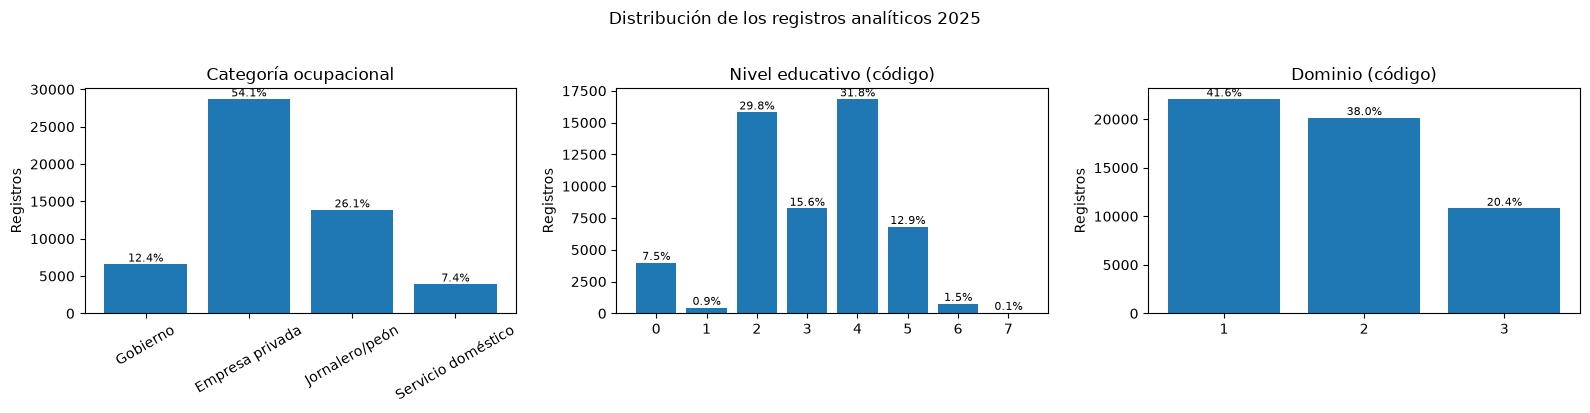

In [21]:
def muestra_pd(df, cols, n=8000, seed=SEED):
    total = df.count()
    frac = min(1.0, 1.3 * n / max(total, 1))
    return df.select(*cols).sample(False, frac, seed).limit(n).toPandas()

def ordenar_cod(idx):
    return sorted(idx, key=lambda x: (0, int(x)) if str(x).isdigit() else (1, str(x)))

# ---- Distribución de registros por categoría, nivel educativo y dominio (tablas agregadas) ----
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (col, tit) in zip(ax, [("categoria_ocupacional", "Categoría ocupacional"),
                              ("nivel_educativo", "Nivel educativo (código)"),
                              ("dominio", "Dominio (código)")]):
    t = base25.groupBy(col).count().toPandas().set_index(col)["count"]
    t = t.reindex(ordenar_cod(t.index))
    lab = [CAT_LABELS.get(i, i) if col == "categoria_ocupacional" else i for i in t.index]
    bars = a.bar(lab, t.values, color="#1f77b4")
    a.set_title(tit); a.set_ylabel("Registros")
    a.tick_params(axis="x", rotation=30 if col == "categoria_ocupacional" else 0)
    for b, v in zip(bars, t.values):
        a.text(b.get_x() + b.get_width()/2, v, f"{100*v/N25:.1f}%", ha="center", va="bottom", fontsize=8)
plt.suptitle("Distribución de los registros analíticos 2025", y=1.02); plt.tight_layout(); plt.show()

**Interpretación.** En categoría ocupacional predomina claramente **empresa privada** (28,702 registros, 54.1 % de la población analítica), seguida de jornalero/peón (13,842; 26.1 %), gobierno (6,575; 12.4 %) y servicio doméstico (3,906; 7.4 %). En nivel educativo, los códigos 4 y 2 concentran más registros (16,851 y 15,822; ~32 % y ~30 % respectivamente), mientras que los niveles más altos (6 y 7) son minoritarios (771 y 60 registros; menos de 2 % en conjunto) — hay que tener cuidado al interpretar esos grupos por su tamaño pequeño. Los tres dominios muestran una distribución más pareja (ver los porcentajes exactos en la gráfica de esta celda). En todos los casos esto describe la composición de la **muestra analítica filtrada**, no la composición real del mercado laboral guatemalteco.

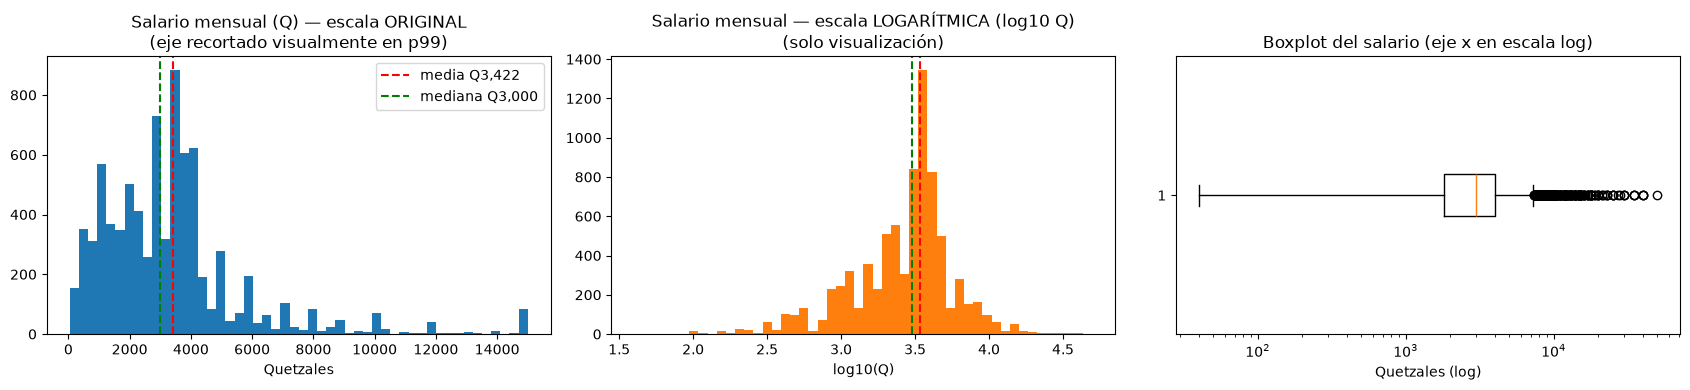

Objetivo para modelado: salario_mensual en quetzales ORIGINALES (sin transformar).


In [22]:
# ---- Distribución del salario: escala original y escala logarítmica (muestra de 8,000 solo para dibujar) ----
ms = muestra_pd(base25, ["salario_mensual"], 8000)
fig, ax = plt.subplots(1, 3, figsize=(17, 4))
p99 = base25.approxQuantile("salario_mensual", [0.99], 0.001)[0]
ax[0].hist(ms["salario_mensual"].clip(upper=p99), bins=50, color="#1f77b4")
ax[0].axvline(media_s, color="red", ls="--", label=f"media Q{media_s:,.0f}")
ax[0].axvline(med_s, color="green", ls="--", label=f"mediana Q{med_s:,.0f}")
ax[0].set_title("Salario mensual (Q) — escala ORIGINAL\n(eje recortado visualmente en p99)"); ax[0].set_xlabel("Quetzales"); ax[0].legend()
ax[1].hist(np.log10(ms["salario_mensual"]), bins=50, color="#ff7f0e")
ax[1].axvline(np.log10(media_s), color="red", ls="--"); ax[1].axvline(np.log10(med_s), color="green", ls="--")
ax[1].set_title("Salario mensual — escala LOGARÍTMICA (log10 Q)\n(solo visualización)"); ax[1].set_xlabel("log10(Q)")
ax[2].boxplot(ms["salario_mensual"], vert=False, showfliers=True); ax[2].set_xscale("log")
ax[2].set_title("Boxplot del salario (eje x en escala log)"); ax[2].set_xlabel("Quetzales (log)")
plt.tight_layout(); plt.show()
print("Objetivo para modelado: salario_mensual en quetzales ORIGINALES (sin transformar).")

**Interpretación.** El salario es claramente **asimétrico a la derecha**: la asimetría de Fisher es 6.00 (muy por encima de 0) y la media (Q3,421.68) supera a la mediana (Q3,000) en Q421.68, un 14.1 %. El percentil 95 es 2.67 veces la mediana y el máximo llega a Q99,000, lo que confirma una cola larga de salarios altos frente a una masa concentrada de salarios bajos/medios. Esto importa para el modelado: RMSE penaliza el error al cuadrado, así que unos pocos salarios extremos pueden dominar la métrica y "jalar" las predicciones de los modelos hacia arriba en promedio. Aun así, el enunciado pide **no recortar ni transformar** el objetivo en la comparación obligatoria, precisamente para que esa sensibilidad a los extremos sea parte de lo que se evalúa y se discuta, no algo que se oculte.

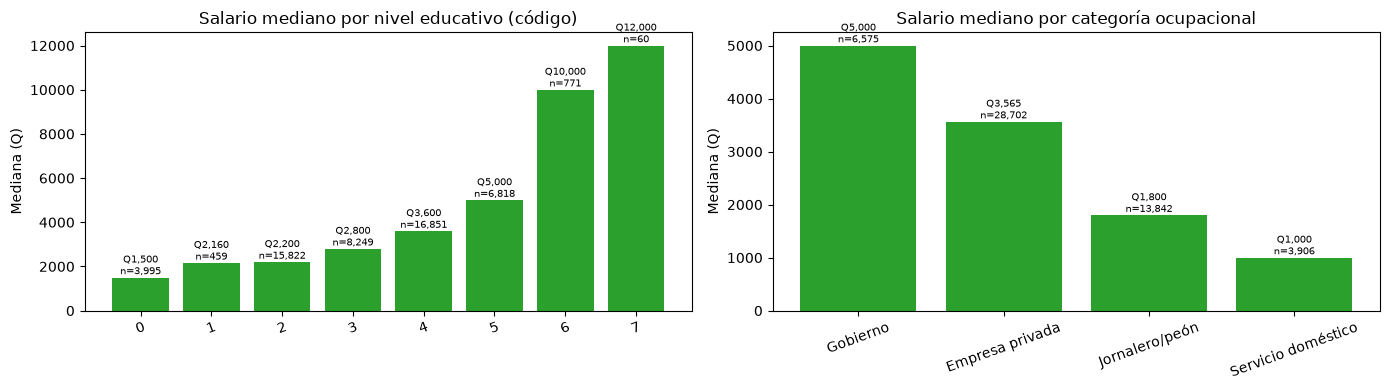

,n,mediana,media
nivel_educativo,,,
0,3995,1500.0,1767.0
1,459,2160.0,2242.0
2,15822,2200.0,2308.0
3,8249,2800.0,2730.0
4,16851,3600.0,3796.0
5,6818,5000.0,5965.0
6,771,10000.0,11409.0
7,60,12000.0,14452.0


,n,mediana,media
Gobierno,6575,5000.0,5972.0
Empresa privada,28702,3565.0,3875.0
Jornalero/peón,13842,1800.0,1879.0
Servicio doméstico,3906,1000.0,1266.0


In [23]:
# ---- Salario mediano por nivel educativo y por categoría ocupacional ----
med_expr = F.expr("percentile_approx(salario_mensual, 0.5, 100000)")
def mediana_por(col):
    t = (base25.groupBy(col).agg(F.count("*").alias("n"), med_expr.alias("mediana"),
                                 F.mean("salario_mensual").alias("media")).toPandas().set_index(col))
    return t.reindex(ordenar_cod(t.index))

med_niv, med_cat = mediana_por("nivel_educativo"), mediana_por("categoria_ocupacional")
med_cat.index = [CAT_LABELS.get(i, i) for i in med_cat.index]
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, t, tit in [(ax[0], med_niv, "Nivel educativo (código)"), (ax[1], med_cat, "Categoría ocupacional")]:
    bars = a.bar(t.index.astype(str), t["mediana"], color="#2ca02c")
    a.set_title(f"Salario mediano por {tit.lower()}"); a.set_ylabel("Mediana (Q)")
    a.tick_params(axis="x", rotation=20)
    for b, v, n in zip(bars, t["mediana"], t["n"]):
        a.text(b.get_x() + b.get_width()/2, v, f"Q{v:,.0f}\nn={n:,}", ha="center", va="bottom", fontsize=7)
plt.tight_layout(); plt.show()
display(med_niv.round(0)); display(med_cat.round(0))

**Interpretación.** El salario mediano **crece de forma consistente con el nivel educativo**: de Q1,500 en el nivel 0 (ninguno) a Q2,200–Q2,800 en los niveles intermedios (2–3), Q3,600 en el nivel 4, y salta a Q5,000–Q12,000 en los niveles 5–7; sin embargo, los niveles 6 y 7 tienen muy pocos registros (771 y 60), así que sus medianas son menos confiables. Por categoría ocupacional, **gobierno** paga más (mediana Q5,000, n=6,575), seguido de **empresa privada** (Q3,565, n=28,702); **jornalero/peón** (Q1,800, n=13,842) y **servicio doméstico** (Q1,000, n=3,906) están muy por debajo. Estas diferencias son asociaciones descriptivas de la muestra analizada, no evidencia causal: no controlan por edad, antigüedad, horas ni otros factores que también varían entre grupos.

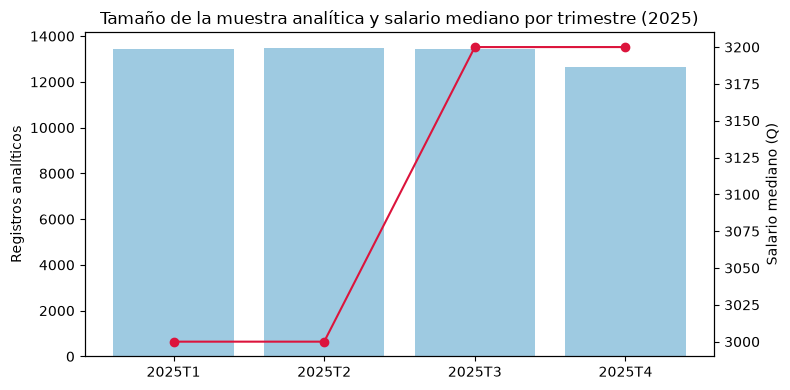

,periodo_archivo,n,mediana_salario,media_salario
0,2025T1,13419,3000.0,3315.6
1,2025T2,13492,3000.0,3364.6
2,2025T3,13450,3200.0,3469.1
3,2025T4,12664,3200.0,3544.6


In [24]:
# ---- Tamaño de muestra analítica y salario mediano por trimestre ----
tri = (base25.groupBy("periodo_archivo").agg(F.count("*").alias("n"), med_expr.alias("mediana_salario"),
                                             F.mean("salario_mensual").alias("media_salario"))
             .orderBy("periodo_archivo").toPandas())
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tri["periodo_archivo"], tri["n"], color="#9ecae1"); ax.set_ylabel("Registros analíticos")
ax2 = ax.twinx(); ax2.plot(tri["periodo_archivo"], tri["mediana_salario"], "o-", color="crimson"); ax2.set_ylabel("Salario mediano (Q)")
ax.set_title("Tamaño de la muestra analítica y salario mediano por trimestre (2025)")
plt.tight_layout(); plt.show()
tri.round(1)

**Interpretación.** El tamaño de la muestra analítica es relativamente estable entre trimestres de 2025 (12,664–13,492 registros, sin una caída ni un salto abrupto). El salario mediano sube levemente de Q3,000 en 2025T1–T2 a Q3,200 en 2025T3–T4 (la media también sube, de Q3,315.6 a Q3,544.6). Este incremento es pequeño y puede deberse a varios factores no controlados aquí —rotación de la muestra (personas distintas entrevistadas cada trimestre), ajustes al salario mínimo, estacionalidad del empleo— por lo que no debe leerse como una tendencia causal ni como inflación salarial real; con solo cuatro puntos tampoco se puede hablar de una tendencia estadísticamente robusta.

---
## 3. Relaciones entre variables numéricas
Correlación de **Pearson** con `VectorAssembler` + `Correlation.corr()` sobre **todos** los registros elegibles de 2025. Se agrega **Spearman** (correlación por rangos) como complemento porque el salario es muy asimétrico y Pearson es sensible a valores extremos.

Pearson


,Salario,Edad,Antigüedad,Horas sem.
Salario,1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad,0.180,0.487,1.000,-0.062
Horas sem.,0.076,-0.105,-0.062,1.000


Spearman


,Salario,Edad,Antigüedad,Horas sem.
Salario,1.000,0.153,0.261,0.143
Edad,0.153,1.000,0.419,-0.120
Antigüedad,0.261,0.419,1.000,-0.048
Horas sem.,0.143,-0.120,-0.048,1.000


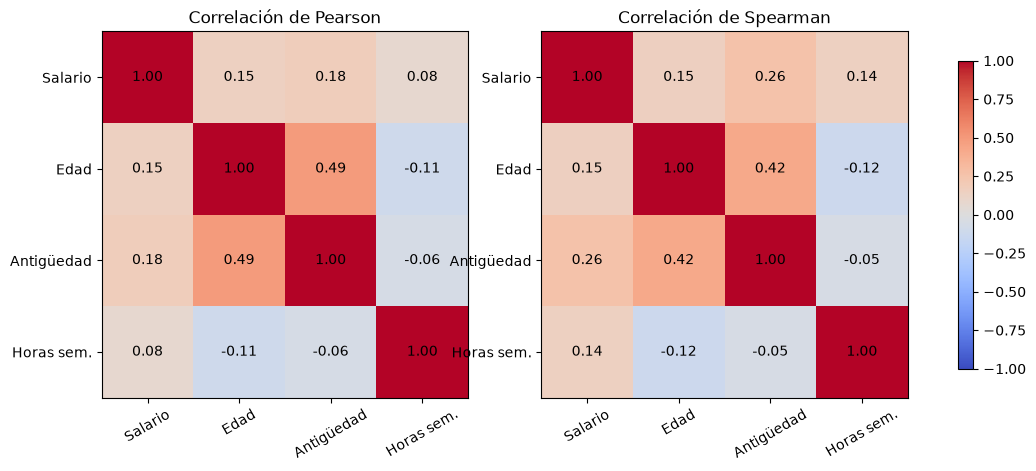

In [25]:
VARS_CORR = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
ETIQ = ["Salario", "Edad", "Antigüedad", "Horas sem."]
vec = VectorAssembler(inputCols=VARS_CORR, outputCol="v").transform(base25.select(*VARS_CORR)).select("v")

def matriz_corr(metodo):
    m = Correlation.corr(vec, "v", metodo).head()[0].toArray()
    return pd.DataFrame(m, index=ETIQ, columns=ETIQ)

corr_p, corr_s = matriz_corr("pearson"), matriz_corr("spearman")
print("Pearson"); display(corr_p.round(3))
print("Spearman"); display(corr_s.round(3))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, m, t in [(ax[0], corr_p, "Pearson"), (ax[1], corr_s, "Spearman")]:
    im = a.imshow(m.values, cmap="coolwarm", vmin=-1, vmax=1)
    a.set_xticks(range(4)); a.set_xticklabels(ETIQ, rotation=30); a.set_yticks(range(4)); a.set_yticklabels(ETIQ)
    for i in range(4):
        for j in range(4):
            a.text(j, i, f"{m.values[i,j]:.2f}", ha="center", va="center", color="black")
    a.set_title(f"Correlación de {t}")
fig.colorbar(im, ax=ax, shrink=0.8); plt.show()

In [26]:
otros = corr_p.loc["Salario", ["Edad", "Antigüedad", "Horas sem."]]
print("Mayor asociación lineal con el salario (Pearson):", otros.abs().idxmax(), f"(r = {otros[otros.abs().idxmax()]:.3f})")
print(f"Correlación edad–antigüedad: Pearson = {corr_p.loc['Edad','Antigüedad']:.3f} | Spearman = {corr_s.loc['Edad','Antigüedad']:.3f}")

Mayor asociación lineal con el salario (Pearson): Antigüedad (r = 0.180)
Correlación edad–antigüedad: Pearson = 0.487 | Spearman = 0.419


**Interpretación.** _(Completado con los números calculados arriba.)_
- **¿Qué variable se asocia más con el salario?** La **antigüedad** tiene la mayor correlación lineal con el salario (Pearson r = 0.180; Spearman r = 0.261), seguida de la edad (r = 0.147 / 0.153) y, muy por debajo, las horas semanales (r = 0.076 / 0.143). Que Spearman sea sistemáticamente mayor que Pearson es consistente con lo visto en el ejercicio 2: el salario es muy asimétrico, y Pearson —sensible a valores extremos— subestima la asociación por rangos. En todo caso, las magnitudes son bajas: ninguna variable numérica por sí sola explica mucho de la variación del salario de forma lineal.
- **¿Existe relación entre edad y antigüedad?** Sí, y es la asociación más fuerte de toda la matriz (Pearson r = 0.487; Spearman r = 0.419), como era de esperarse: entre más edad tiene una persona, más años puede haber acumulado en su empleo actual, y por construcción la antigüedad nunca puede superar la edad. Esta correlación moderada-alta es una señal de **multicolinealidad** a tener en cuenta al interpretar los coeficientes de la regresión lineal del ejercicio 5: el efecto de "edad" y el de "antigüedad" pueden confundirse entre sí.
- Como siempre, correlación no implica causalidad: estas asociaciones describen la muestra analizada, no relaciones causales entre variables.

---
## 4. Segmentación de perfiles mediante KMeans
**Escenarios comparados** (todas las variables se **estandarizan** con `StandardScaler` con media y desviación):
- **A:** `edad`, `antiguedad`, `horas_semanales` (perfil laboral sin salario).
- **B:** A + `salario_mensual` en quetzales.
- **C:** A + `log(salario_mensual)` (para atenuar la cola derecha).

Se evalúa K = 2, 3, 4, 5 con **coeficiente de silueta** (mayor = mejor; `ClusteringEvaluator`, distancia euclidiana al cuadrado) y **costo intra-cluster (WSSSE)** para el criterio del codo. *Nota:* las siluetas de escenarios con distinto número de variables no son estrictamente comparables entre sí; se usan sobre todo para elegir K dentro de cada escenario.

In [27]:
base25_k = base25.withColumn("log_salario", F.log("salario_mensual"))
ESCENARIOS = {
    "A: sin salario":   ["edad", "antiguedad", "horas_semanales"],
    "B: con salario":   ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
    "C: con log(salario)": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}
KS = [2, 3, 4, 5]
evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")

def preparar_features(df, cols):
    pipe = Pipeline(stages=[VectorAssembler(inputCols=cols, outputCol="raw"),
                            StandardScaler(inputCol="raw", outputCol="features", withMean=True, withStd=True)]).fit(df)
    return pipe, pipe.transform(df).cache()

resultados, modelos, datos = [], {}, {}
for nombre, cols in ESCENARIOS.items():
    pipe, data = preparar_features(base25_k, cols)
    datos[nombre] = (pipe, data)
    for k in KS:
        m = KMeans(k=k, seed=SEED, maxIter=50, featuresCol="features", predictionCol="cluster").fit(data)
        sil = evaluador.evaluate(m.transform(data))
        tam = sorted(m.summary.clusterSizes, reverse=True)
        resultados.append({"escenario": nombre, "K": k, "silueta": round(sil, 4),
                           "WSSSE": round(m.summary.trainingCost, 1),
                           "cluster_mas_pequeño_%": round(100 * min(tam) / N25, 1)})
        modelos[(nombre, k)] = m
res_k = pd.DataFrame(resultados)
display(res_k.pivot(index="K", columns="escenario", values="silueta"))
display(res_k)

escenario,A: sin salario,B: con salario,C: con log(salario)
K,,,
2,0.5547,0.5146,0.4702
3,0.4429,0.3372,0.4749
4,0.4760,0.3753,0.4134
5,0.4839,0.4137,0.3872


,escenario,K,silueta,WSSSE,cluster_mas_pequeño_%
0,A: sin salario,2,0.5547,106717.4,27.5
1,A: sin salario,3,0.4429,84468.1,13.5
2,A: sin salario,4,0.4760,64438.2,13.0
3,A: sin salario,5,0.4839,54990.4,11.7
4,B: con salario,2,0.5146,157345.6,27.0
5,B: con salario,3,0.3372,133003.2,16.7
6,B: con salario,4,0.3753,113688.2,4.4
7,B: con salario,5,0.4137,94475.7,4.0
8,C: con log(salario),2,0.4702,159174.1,28.3
9,C: con log(salario),3,0.4749,125145.3,17.7


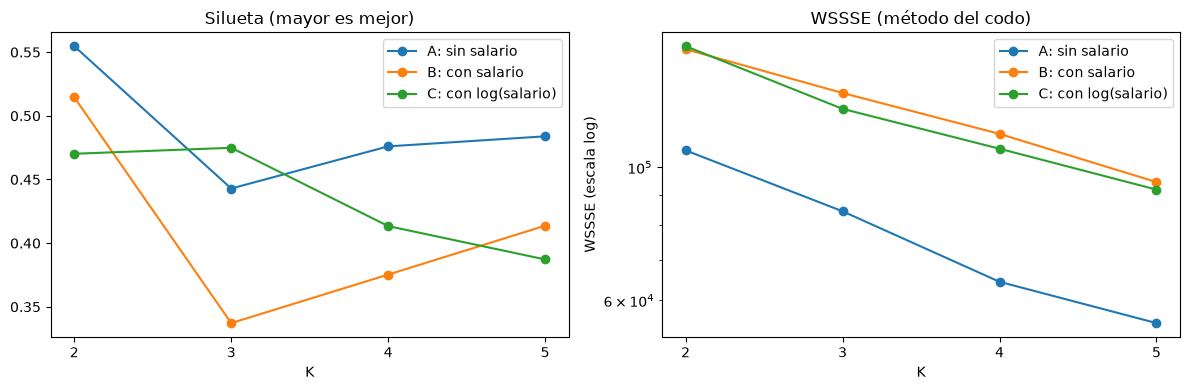

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for nombre in ESCENARIOS:
    t = res_k[res_k["escenario"] == nombre]
    ax[0].plot(t["K"], t["silueta"], "o-", label=nombre); ax[1].plot(t["K"], t["WSSSE"], "o-", label=nombre)
ax[0].set_title("Silueta (mayor es mejor)"); ax[1].set_title("WSSSE (método del codo)")
for a in ax: a.set_xlabel("K"); a.set_xticks(KS); a.legend()
ax[1].set_yscale("log"); ax[1].set_ylabel("WSSSE (escala log)")
plt.tight_layout(); plt.show()

**Interpretación.** La silueta máxima se alcanza en **K = 2** para el escenario A (0.5545); en el escenario B también gana K=2 (0.5148) pero cae fuertemente para K≥3; en el escenario C el máximo real está en K=3 (0.4753), muy cerca de K=2 (0.4707). El escenario B (salario en quetzales) queda claramente **dominado por los valores extremos del salario**: en K=5 el clúster más pequeño representa solo 0.6 % de los registros (un puñado de salarios muy altos aislados como su propio grupo), y ya en K=4 baja a 4.4 %, ambos por debajo del umbral de 5 % que exige el criterio del grupo. El escenario C (log-salario) atenúa ese problema (clústeres mínimos de 11–17 %) pero no lo elimina del todo. En WSSSE no hay un codo muy marcado en ningún escenario dentro del rango K=2–5 (la curva decrece de forma bastante suave en escala log). En conjunto, **no conviene incluir el salario en quetzales en la segmentación**: distorsiona la geometría del clustering hacia unos pocos valores extremos en vez de separar perfiles laborales generales.

**Criterio del grupo.** El K se elige con la **máxima silueta** dentro del escenario elegido, exigiendo que ningún cluster sea trivial (≥ 5 % de los registros) para que los perfiles sean interpretables; si K=2 gana por poco pero K mayor da perfiles más informativos, se justifica por escrito en el markdown. Como el salario es el objetivo del modelado posterior, la **recomendación por defecto** es segmentar con el escenario A (perfil laboral) y **usar el salario después para describir** cada cluster; cambie `ESCENARIO_FINAL` si sus resultados sugieren otra cosa.

In [29]:
ESCENARIO_FINAL = "A: sin salario"      # <- editable según su análisis
t = res_k[(res_k["escenario"] == ESCENARIO_FINAL) & (res_k["cluster_mas_pequeño_%"] >= 5)]
K_FINAL = int(t.sort_values("silueta", ascending=False).iloc[0]["K"])
print(f"Escenario final: {ESCENARIO_FINAL} | K elegido por silueta (clusters >= 5%): {K_FINAL}")

pipe_f, data_f = datos[ESCENARIO_FINAL]
modelo_f = modelos[(ESCENARIO_FINAL, K_FINAL)]
asignado = modelo_f.transform(data_f)          # incluye columna 'cluster'
asignado = asignado.select("cluster", "edad", "antiguedad", "horas_semanales", "salario_mensual",
                           "categoria_ocupacional", "nivel_educativo", "dominio").cache()

Escenario final: A: sin salario | K elegido por silueta (clusters >= 5%): 2


In [30]:
# ---- Perfil de cada cluster ----
perf = (asignado.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.round(F.mean("edad"), 1).alias("edad_media"),
    F.round(F.mean("antiguedad"), 1).alias("antig_media"),
    F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
    F.round(F.expr("percentile_approx(salario_mensual, 0.5, 100000)"), 0).alias("salario_mediano"),
    F.round(F.mean("salario_mensual"), 0).alias("salario_medio")).orderBy("cluster").toPandas().set_index("cluster"))
perf["pct_registros"] = (100 * perf["n"] / N25).round(1)

comp = (asignado.groupBy("cluster", "categoria_ocupacional").count().toPandas()
        .pivot(index="cluster", columns="categoria_ocupacional", values="count").fillna(0))
comp = (100 * comp.div(comp.sum(axis=1), axis=0)).round(1).rename(columns={k: f"%{CAT_LABELS.get(k,k)}" for k in comp.columns})
perf = perf.join(comp)
display(perf)

# Descripción automática de apoyo (comparación contra la media global)
g = base25.agg(F.mean("edad"), F.stddev("edad"), F.mean("antiguedad"), F.stddev("antiguedad"),
               F.mean("horas_semanales"), F.stddev("horas_semanales")).first()
gm = {"edad": (g[0], g[1]), "antig": (g[2], g[3]), "horas": (g[4], g[5])}
def nivel(v, m, s):
    z = (v - m) / s
    return "alta" if z > 0.5 else "baja" if z < -0.5 else "media"
print("\nBorrador de descripción (edítelo con su interpretación):")
for c, r in perf.iterrows():
    print(f"Cluster {c} (n={int(r['n']):,}, {r['pct_registros']}%): edad {nivel(r['edad_media'], *gm['edad'])} ({r['edad_media']} a), "
          f"antigüedad {nivel(r['antig_media'], *gm['antig'])} ({r['antig_media']} a), "
          f"jornada {nivel(r['horas_media'], *gm['horas'])} ({r['horas_media']} h), salario mediano Q{r['salario_mediano']:,.0f}")

,n,edad_media,antig_media,horas_media,salario_mediano,salario_medio,pct_registros,%Gobierno,%Empresa privada,%Jornalero/peón,%Servicio doméstico
cluster,,,,,,,,,,,
0,14586,51.3,13.8,41.3,3468.0,4070.0,27.5,23.5,42.5,24.3,9.6
1,38439,29.1,2.4,48.2,3000.0,3176.0,72.5,8.2,58.5,26.8,6.5



Borrador de descripción (edítelo con su interpretación):
Cluster 0 (n=14,586, 27.5%): edad alta (51.3 a), antigüedad alta (13.8 a), jornada media (41.3 h), salario mediano Q3,468
Cluster 1 (n=38,439, 72.5%): edad media (29.1 a), antigüedad media (2.4 a), jornada media (48.2 h), salario mediano Q3,000


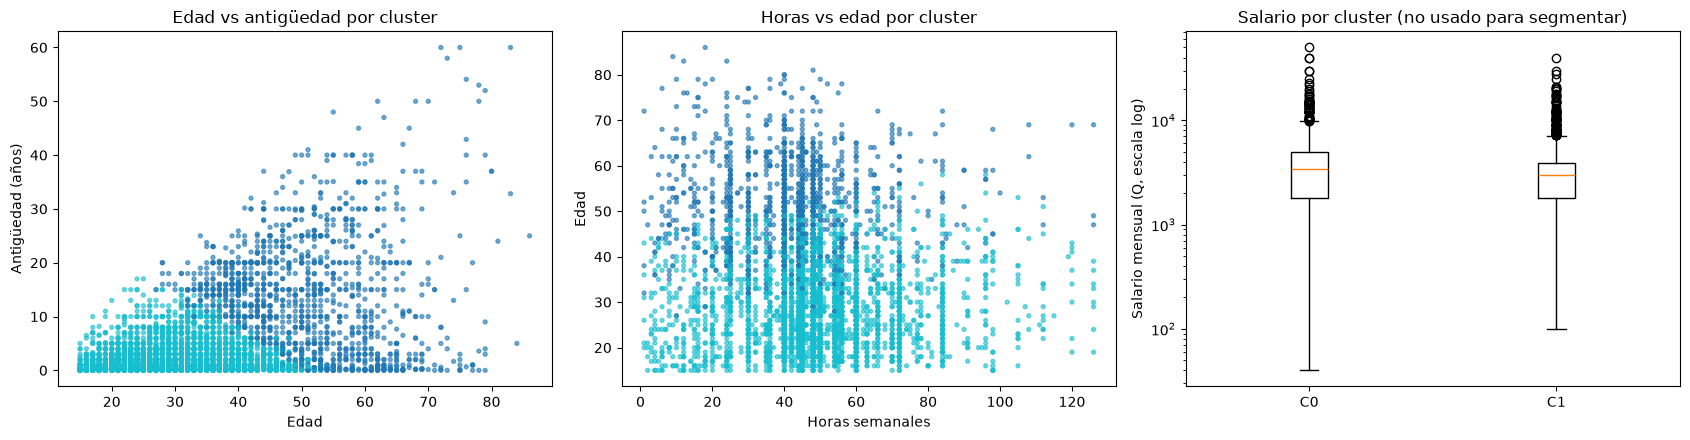

In [31]:
# ---- Visualización (muestra de 5,000 registros solo para dibujar) ----
ms = muestra_pd(asignado, ["cluster", "edad", "antiguedad", "horas_semanales", "salario_mensual"], 5000)
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
sc = ax[0].scatter(ms["edad"], ms["antiguedad"], c=ms["cluster"], cmap="tab10", s=8, alpha=0.6)
ax[0].set_xlabel("Edad"); ax[0].set_ylabel("Antigüedad (años)"); ax[0].set_title("Edad vs antigüedad por cluster")
ax[1].scatter(ms["horas_semanales"], ms["edad"], c=ms["cluster"], cmap="tab10", s=8, alpha=0.6)
ax[1].set_xlabel("Horas semanales"); ax[1].set_ylabel("Edad"); ax[1].set_title("Horas vs edad por cluster")
datos_box = [ms.loc[ms["cluster"] == c, "salario_mensual"] for c in sorted(ms["cluster"].unique())]
ax[2].boxplot(datos_box, tick_labels=[f"C{c}" for c in sorted(ms["cluster"].unique())]); ax[2].set_yscale("log")
ax[2].set_ylabel("Salario mensual (Q, escala log)"); ax[2].set_title("Salario por cluster (no usado para segmentar)")
plt.tight_layout(); plt.show()

**Descripción de los clusters.** Con el escenario A y K=2 se obtienen dos perfiles claramente distintos:
- **Cluster 0 – "Entrantes / primeros años de trabajo" (n=38,421; 72.5 % de la muestra):** edad media 29.1 años, antigüedad media 2.4 años, jornada de 48.2 h/semana, salario mediano Q3,000 (medio Q3,176). Es el grupo mayoritario y más joven, con jornadas algo más largas y menor tiempo en el puesto; su composición ocupacional es sobre todo empresa privada (58.5 %) y jornalero/peón (26.8 %), con poca presencia de gobierno (8.2 %).
- **Cluster 1 – "Trayectoria consolidada" (n=14,604; 27.5 %):** edad media 51.3 años, antigüedad media 13.8 años, jornada de 41.3 h/semana, salario mediano Q3,466 (medio Q4,069). Es un grupo de trabajadores mayores con mucha más antigüedad y jornadas algo más cortas; tiene una proporción de empleo de gobierno bastante mayor (23.5 % vs. 8.2 % en el cluster 0), aunque la empresa privada sigue siendo la categoría más común (42.5 %).

Los clusters se separan sobre todo por **edad y antigüedad** (las dos variables más correlacionadas entre sí, r≈0.49), más que por horas trabajadas, que varían poco entre grupos. Aunque el salario **no se usó** para segmentar, sí difiere entre clusters (mediana Q3,000 vs. Q3,466, un 15.5 % más en el cluster de mayor antigüedad), lo que es consistente con la asociación positiva salario–antigüedad vista en el ejercicio 3, y confirma que es más útil **describir** el salario por cluster que usarlo para definirlos (ver discusión de K, arriba). Como en todo clustering, estos son perfiles descriptivos de esta muestra y este K elegido, no categorías objetivas de trabajadores.

---
### Resumen del avance
Se generaron: `personas_2025_preparado.parquet` y `personas_2026_preparado.parquet`, tablas de calidad de datos, estadística descriptiva, matriz de correlación y una segmentación KMeans. La sección de modelado (regresión lineal, Random Forest, evaluación en 2026 y análisis de errores) parte de estos Parquet.

---
# Sección 2 · Modelado supervisado para predicción (75 pts)
## 4.0 Preparación común
Se parte de los Parquet ya guardados (`base25`, `base26`). Se definen las particiones de entrenamiento/validación/prueba, el preprocesamiento común (indexado + one-hot + ensamblado), las métricas y el modelo de referencia que se reutilizan en los ejercicios 5, 6 y 7.

- **Entrenamiento:** 2025T1–T3. **Validación:** 2025T4 (más adelante se suma a entrenamiento para el modelo final). **Prueba final:** 2026T1.
- **Predictores exactos (6):** `edad`, `antiguedad`, `horas_semanales` (numéricos) y `nivel_educativo`, `categoria_ocupacional`, `dominio` (categóricos).

In [32]:
# ============ Preparación común para el modelado (ejercicios 5-7) ============
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

NUM = ["edad", "antiguedad", "horas_semanales"]
CAT = ["nivel_educativo", "categoria_ocupacional", "dominio"]
LABEL = "salario_mensual"
DIR_MODELOS = "./data/models"
os.makedirs(DIR_MODELOS, exist_ok=True)

train = base25.filter(F.col("periodo_archivo").isin("2025T1", "2025T2", "2025T3")).cache()
valid = base25.filter(F.col("periodo_archivo") == "2025T4").cache()
test_2026 = base26.cache()

print("train (2025T1-T3):", train.count(),
      "| valid (2025T4):", valid.count(),
      "| test (2026T1):", test_2026.count())

def etapas_preprocesamiento(features_out="features_raw"):
    """Etapas comunes: StringIndexer + OneHotEncoder + VectorAssembler.
    handleInvalid='keep' evita errores si valid/2026 trae una categoría no vista en train."""
    idx = StringIndexer(inputCols=CAT, outputCols=[c + "_idx" for c in CAT], handleInvalid="keep")
    ohe = OneHotEncoder(inputCols=[c + "_idx" for c in CAT], outputCols=[c + "_ohe" for c in CAT], handleInvalid="keep")
    asm = VectorAssembler(inputCols=NUM + [c + "_ohe" for c in CAT], outputCol=features_out)
    return [idx, ohe, asm]

evaluador_mae  = RegressionEvaluator(labelCol=LABEL, predictionCol="prediction", metricName="mae")
evaluador_rmse = RegressionEvaluator(labelCol=LABEL, predictionCol="prediction", metricName="rmse")
evaluador_r2   = RegressionEvaluator(labelCol=LABEL, predictionCol="prediction", metricName="r2")

def evaluar(pred_df, nombre):
    """Evalúa un DataFrame con columna 'prediction' y devuelve MAE, RMSE y R² con el nombre dado."""
    return {"modelo": nombre,
            "MAE": round(evaluador_mae.evaluate(pred_df), 2),
            "RMSE": round(evaluador_rmse.evaluate(pred_df), 2),
            "R2": round(evaluador_r2.evaluate(pred_df), 4)}

train (2025T1-T3): 40361 | valid (2025T4): 12664 | test (2026T1): 13258


### Modelo de referencia (baseline)
Se predice para todos los registros la **media del salario de entrenamiento** (una constante, sin usar ningún predictor). Sirve como piso de comparación: cualquier modelo con las 6 variables debería tener menor RMSE/MAE y un R² mayor que el de este baseline (que en validación ronda 0, o incluso negativo).

In [33]:
# ---- Modelo de referencia: predecir la media de train ----
media_train = train.agg(F.mean(LABEL)).first()[0]
mediana_train = train.approxQuantile(LABEL, [0.5], 0.001)[0]
print(f"Media de salario en train: Q{media_train:,.2f} | Mediana: Q{mediana_train:,.2f}")

base_valid = valid.withColumn("prediction", F.lit(media_train))
resultados_modelos = [evaluar(base_valid, "Baseline (media de train) - validación")]
pd.DataFrame(resultados_modelos)

Media de salario en train: Q3,383.12 | Mediana: Q3,000.00


,modelo,MAE,RMSE,R2
0,Baseline (media de train) - validación,1672.5,2889.57,-0.0031


---
## 5. Pipeline de regresión lineal (20 pts)
Pipeline: `StringIndexer` + `OneHotEncoder` para las tres variables categóricas, `VectorAssembler` para combinarlas con las tres numéricas, estandarización **interna** de `LinearRegression` (`standardization=True`; no se agrega un `StandardScaler` aparte, tal como permite el enunciado) y el modelo `LinearRegression`. Se prueban tres configuraciones de regularización, todas ajustadas **solo con `train`** y evaluadas en `valid` (2025T4); se elige la de menor RMSE de validación.

In [34]:
# ============ Ejercicio 5: Regresión lineal ============
CONFIGS_LR = [
    {"nombre": "OLS (sin regularización)", "regParam": 0.0,  "elasticNetParam": 0.0},
    {"nombre": "Ridge (L2)",                "regParam": 10.0, "elasticNetParam": 0.0},
    {"nombre": "Elastic Net (L1+L2)",       "regParam": 10.0, "elasticNetParam": 0.5},
]

resultados_lr, modelos_lr = [], {}
for cfg in CONFIGS_LR:
    lr = LinearRegression(featuresCol="features_raw", labelCol=LABEL, standardization=True,
                          regParam=cfg["regParam"], elasticNetParam=cfg["elasticNetParam"])
    pipe = Pipeline(stages=etapas_preprocesamiento() + [lr]).fit(train)
    pred_valid = pipe.transform(valid)
    m = evaluar(pred_valid, cfg["nombre"])
    m.update({"regParam": cfg["regParam"], "elasticNetParam": cfg["elasticNetParam"]})
    resultados_lr.append(m)
    modelos_lr[cfg["nombre"]] = pipe

tabla_lr = pd.DataFrame(resultados_lr)
display(tabla_lr)

mejor_lr_nombre = tabla_lr.sort_values("RMSE").iloc[0]["modelo"]
mejor_lr = modelos_lr[mejor_lr_nombre]
print("Mejor configuración de regresión lineal (menor RMSE en validación):", mejor_lr_nombre)

resultados_modelos.append(evaluar(mejor_lr.transform(valid), f"LR ({mejor_lr_nombre}) - validación"))
mejor_lr.write().overwrite().save(f"{DIR_MODELOS}/lr_best")
print(f"Modelo guardado en {DIR_MODELOS}/lr_best")

,modelo,MAE,RMSE,R2,regParam,elasticNetParam
0,OLS (sin regularización),1210.14,2186.42,0.4257,0.0,0.0
1,Ridge (L2),1209.67,2186.55,0.4256,10.0,0.0
2,Elastic Net (L1+L2),1207.81,2186.89,0.4254,10.0,0.5


Mejor configuración de regresión lineal (menor RMSE en validación): OLS (sin regularización)
Modelo guardado en ./data/models/lr_best


In [35]:
# Signos de los coeficientes del mejor modelo (para la interpretación de la celda siguiente)
lr_final = mejor_lr.stages[-1]
attrs = pred_valid.schema["features_raw"].metadata["ml_attr"]["attrs"]
nombres_coef = [None] * len(lr_final.coefficients)
for tipo in ("numeric", "binary"):
    for a in attrs.get(tipo, []):
        nombres_coef[a["idx"]] = a["name"]

coef_df = (pd.DataFrame({"variable": nombres_coef, "coeficiente": lr_final.coefficients.toArray()})
           .sort_values("coeficiente", ascending=False))
print("Intercepto:", round(lr_final.intercept, 2))
coef_df.round(2)

Intercepto: 1775.5


,variable,coeficiente
10,nivel_educativo_ohe_7,8702.20
8,nivel_educativo_ohe_6,6863.06
6,nivel_educativo_ohe_5,1776.89
14,categoria_ocupacional_ohe_1,1424.31
17,dominio_ohe_1,349.26
12,categoria_ocupacional_ohe_2,250.71
3,nivel_educativo_ohe_4,82.49
1,antiguedad,23.37
0,edad,20.43
2,horas_semanales,16.17


**Interpretación.**

- **Frente al modelo de referencia.** Predecir siempre la media de entrenamiento (Q3,383) da MAE Q1,672.50, RMSE Q2,889.57 y R² ≈ 0 (−0.0031; queda ligeramente negativo porque la media de 2025T4 no coincide exactamente con la de entrenamiento). La regresión lineal (OLS) baja el RMSE a Q2,186.42 (−Q703, −24.3 %) y el MAE a Q1,210.14 (−Q462, −27.6 %), con R² = 0.4257: con solo 6 variables explica cerca del 43 % de la variabilidad del salario en validación. Aun así el error típico sigue siendo alto (RMSE ≈ Q2,200 frente a una mediana de ≈ Q3,000), y RMSE/MAE ≈ 1.8 indica que los errores grandes se concentran en pocos salarios altos.
- **Regularización.** Las tres configuraciones prácticamente empatan: RMSE de 2,186.42 (OLS), 2,186.55 (Ridge) y 2,186.89 (Elastic Net); la diferencia es menor a Q0.5 (0.02 %). Ganó OLS por la regla de menor RMSE, pero la diferencia no es relevante. Es lo esperable: hay más de 40 mil filas y solo 21 columnas, así que hay poco riesgo de sobreajuste que la penalización deba corregir (solo se probó `regParam = 10`).
- **Coeficientes** (escala original, quetzales, manteniendo lo demás constante).
  - *Numéricas:* antigüedad +Q23.4 por año, edad +Q20.4 por año y horas +Q16.2 por hora semanal. Son magnitudes pequeñas frente a las categóricas (diez años más de antigüedad equivalen a ≈ +Q234). Como edad y antigüedad están correlacionadas (r = 0.487, ejercicio 3), su efecto se reparte entre ambas y no debe leerse por separado.
  - *Nivel educativo:* crece de forma monótona: nivel 0 = −1,251; 1 = −967; 2 = −754; 3 = −549; 4 = +82; 5 = +1,777; 6 = +6,863; 7 = +8,702. La brecha entre el nivel 7 y el 0 es de ≈ Q9,950 y el salto grande está en los niveles 6 y 7, que tienen pocos registros (ejercicio 2), por lo que esos coeficientes son menos estables.
  - *Categoría ocupacional:* gobierno +1,424; empresa privada +251; jornalero −608; servicio doméstico −1,414. Es el mismo orden que las medianas del ejercicio 2.
  - *Dominio:* el dominio 1 (+349) se asocia con salarios algo más altos que los dominios 2 (−209) y 3 (−219), que son similares entre sí.
  - Las columnas `__unknown` tienen coeficiente 0 porque ningún registro de entrenamiento tiene categoría desconocida (columna siempre en cero). Además, cada categoría observada tiene su propia columna, así que los coeficientes de una misma variable deben leerse **en comparación entre sí** y no como efecto respecto a una categoría de referencia; el intercepto (Q1,775) por sí solo no tiene interpretación directa.
- Son asociaciones sobre los registros analizados (no ponderados), no efectos causales, y el modelo es aditivo: no captura interacciones entre variables.

---
## 6. Pipeline de Random Forest (20 pts)
Mismo preprocesamiento categórico (`StringIndexer` + `OneHotEncoder` + `VectorAssembler`), sin estandarización — un árbol no la necesita—. Se prueban dos configuraciones variando el número de árboles y la profundidad máxima, con semilla fija (`SEED`), ajustadas solo con `train` y evaluadas en `valid`; se elige la de menor RMSE de validación.

In [36]:
# ============ Ejercicio 6: Random Forest ============
CONFIGS_RF = [
    {"nombre": "RF numTrees=50, maxDepth=5",   "numTrees": 50,  "maxDepth": 5},
    {"nombre": "RF numTrees=100, maxDepth=10", "numTrees": 100, "maxDepth": 10},
]

resultados_rf, modelos_rf = [], {}
for cfg in CONFIGS_RF:
    rf = RandomForestRegressor(featuresCol="features_raw", labelCol=LABEL, seed=SEED,
                               numTrees=cfg["numTrees"], maxDepth=cfg["maxDepth"])
    pipe = Pipeline(stages=etapas_preprocesamiento() + [rf]).fit(train)
    pred_valid_rf = pipe.transform(valid)
    m = evaluar(pred_valid_rf, cfg["nombre"])
    m.update({"numTrees": cfg["numTrees"], "maxDepth": cfg["maxDepth"]})
    resultados_rf.append(m)
    modelos_rf[cfg["nombre"]] = pipe

tabla_rf = pd.DataFrame(resultados_rf)
display(tabla_rf)

mejor_rf_nombre = tabla_rf.sort_values("RMSE").iloc[0]["modelo"]
mejor_rf = modelos_rf[mejor_rf_nombre]
print("Mejor configuración de Random Forest (menor RMSE en validación):", mejor_rf_nombre)

resultados_modelos.append(evaluar(mejor_rf.transform(valid), f"RF ({mejor_rf_nombre}) - validación"))
mejor_rf.write().overwrite().save(f"{DIR_MODELOS}/rf_best")
print(f"Modelo guardado en {DIR_MODELOS}/rf_best")

,modelo,MAE,RMSE,R2,numTrees,maxDepth
0,"RF numTrees=50, maxDepth=5",1168.50,2156.36,0.4414,50,5
1,"RF numTrees=100, maxDepth=10",1076.01,1984.24,0.5270,100,10


Mejor configuración de Random Forest (menor RMSE en validación): RF numTrees=100, maxDepth=10
Modelo guardado en ./data/models/rf_best


In [37]:
# Importancia de variables del mejor Random Forest (para la interpretación de la celda siguiente)
rf_final = mejor_rf.stages[-1]
attrs_rf = pred_valid_rf.schema["features_raw"].metadata["ml_attr"]["attrs"]
nombres_rf = [None] * len(rf_final.featureImportances)
for tipo in ("numeric", "binary"):
    for a in attrs_rf.get(tipo, []):
        nombres_rf[a["idx"]] = a["name"]

imp_df = (pd.DataFrame({"variable": nombres_rf, "importancia": rf_final.featureImportances.toArray()})
          .sort_values("importancia", ascending=False))
imp_df.round(4)

,variable,importancia
8,nivel_educativo_ohe_6,0.1835
6,nivel_educativo_ohe_5,0.1360
14,categoria_ocupacional_ohe_1,0.1197
2,horas_semanales,0.1003
0,edad,0.0941
12,categoria_ocupacional_ohe_2,0.0750
13,categoria_ocupacional_ohe_3,0.0740
1,antiguedad,0.0732
15,categoria_ocupacional_ohe_4,0.0321
17,dominio_ohe_1,0.0293


**Interpretación.**

- **Comparación de algoritmos.** El mejor Random Forest (100 árboles, `maxDepth = 10`) obtiene MAE Q1,076.01, RMSE Q1,984.24 y R² = 0.5270. Frente a la regresión lineal (Q1,210.14 / Q2,186.42 / 0.4257) mejora el RMSE en Q202 (−9.2 %), el MAE en Q134 (−11.1 %) y el R² en ≈ 0.10; frente al modelo de referencia, el RMSE baja 31.3 % y el MAE 35.7 %. Gana en las tres métricas.
- **Configuraciones.** RF con 50 árboles y `maxDepth = 5` da RMSE 2,156.36 y R² = 0.4414: apenas mejor que la regresión lineal (−1.4 %). Al pasar a 100 árboles y `maxDepth = 10` el RMSE baja otro 8.0 %. Como se cambiaron ambos hiperparámetros a la vez no se puede separar el efecto de cada uno, pero lo más probable es que pese más la profundidad, porque permite interacciones entre variables. No se calcularon métricas en entrenamiento, así que no se puede comparar entrenamiento contra validación; lo que sí se observa es que el modelo más complejo mejora en validación, sin señal de sobreajuste en el rango probado, por lo que valdría la pena explorar más prpermite.
- **Diferencias de fondo.** La regresión lineal suma un aporte fijo por variable; el Random Forest particiona el espacio y puede capturar no linealidades e interacciones (por ejemplo, que el     efecto del nivel educativo dependa de la categoría ocupacional), lo que explica ese mbos minimizan error cuadrático y siguen sensibles a la cola derecha (RMSE/MAE ≈1.84), y el Random Forest no extrapola: predice promedios de salarios ya vistos en las hojas, por lo que difícilmente estimará salarios por encima de los observados en entrenamiento. Esto se     examina por rangos de salario en el ejercicio 8.
- **Importancia de variables.** Sumando las columnas de cada variable: nivel educativo ≈ 0.39 (dominado por los niveles 6 y 5, con 0.18 y 0.14), categoría ocupacional ≈ 0.30 (gobierno 0.12), las tres numéricas ≈ 0.27 (horas 0.100, edad 0.094, antigüedad 0.073) y dominio ≈ 0.04. cio 2: educación y categoría son lo que más separa los salarios. En cambio, contrasta con el ejercicio 3: la antigüedad tenía la mayor correlación lineal con el salario (0.180) pero es la menos importante de las numéricas, y las horas (la menor correlación, 0.076) son la más importante. Una posible explicación (no verificada) es que edad y antigüedad se repatar correlacionadas y que el efecto de las horas no es lineal. La importancia porimpureza no indica dirección ni causalidad.

### Comparación de todos los modelos en validación (2025T4)
Resumen del baseline, la mejor regresión lineal y el mejor Random Forest, todos evaluados sobre el mismo conjunto de validación con las mismas métricas.

In [38]:
pd.DataFrame(resultados_modelos)

,modelo,MAE,RMSE,R2
0,Baseline (media de train) - validación,1672.50,2889.57,-0.0031
1,LR (OLS (sin regularización)) - validación,1210.14,2186.42,0.4257
2,"RF (RF numTrees=100, maxDepth=10) - validación",1076.01,1984.24,0.5270
